In [1]:
# ============================================================
# SECTION 0 — Install Dependencies
# ============================================================

!pip install scikit-learn networkx sentence-transformers

In [2]:
# ============================================================
# SECTION 1 — Imports
# ============================================================

from google.colab import drive

import os
import pickle
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# ============================================================
# SECTION 2 — Load Graph + Communities
# ============================================================

# SECTION 2A - Load Graphs

drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/Colab_Notebooks/LLMs/ARIA_Lite_v2"

NEW_GRAPH_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "aria_lite_graph_v2_1_communities_v1.pkl"
)

with open(NEW_GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

print("Graph loaded")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# SECTION 2B - Load communities

community_summaries = G.graph["community_summaries"]
print("Communities:", len(community_summaries))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Graph loaded
Nodes: 2105
Edges: 22506
Communities: 11


In [4]:
# ============================================================
# SECTION 3 — Load SPECTER
# ============================================================

model = SentenceTransformer("allenai-specter")

print("SPECTER loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/allenai-specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SPECTER loaded


In [5]:
# ============================================================
# SECTION 4 — Community Retrieval
# ============================================================

def retrieve_communities(
    query,
    community_summaries,
    embedder,
    top_k=3
):
    """
    Global retrieval.

    Query embedding
    →
    Community embedding similarity
    →
    Top-k communities
    """

    query_embedding = embedder.encode(
        query,
        normalize_embeddings=True
    )

    results = []

    for cid, info in community_summaries.items():

        community_embedding = info["embedding"]

        sim = cosine_similarity(
            [query_embedding],
            [community_embedding]
        )[0][0]

        results.append({
            "community_id": cid,
            "score": float(sim),
            "summary": info["summary"],
            "top_entities": info["top_entities"],
            "num_entities": info["num_entities"],
            "num_sections": info["num_sections"]
        })

    results = sorted(
        results,
        key=lambda x: x["score"],
        reverse=True
    )

    return results[:top_k]

In [6]:
# ============================================================
# SECTION 5 — Retrieve Supporting Sections
# ============================================================

def get_community_sections(
    graph,
    community_id,
    max_sections=3
):
    """
    Return representative sections
    supporting a community.
    """

    sections = []

    for node, data in graph.nodes(data=True):

        if data.get("type") != "entity":
            continue

        if data.get("community_id") != community_id:
            continue

        for nbr in graph.neighbors(node):

            nbr_data = graph.nodes[nbr]

            if nbr_data.get("type") == "section":

                sections.append(nbr)

    sections = list(set(sections))

    return sections[:max_sections]

In [7]:
# ============================================================
# SECTION 6 — Build Context Package
# ============================================================

def build_global_context(
    graph,
    retrieved_communities
):
    """
    Build context package for LLM.
    """

    context = []

    for community in retrieved_communities:

        cid = community["community_id"]

        community_sections = get_community_sections(
            graph,
            cid
        )

        section_texts = []

        for sid in community_sections:

            text = graph.nodes[sid].get("text", "")

            if len(text) > 0:

                section_texts.append({
                    "section_id": sid,
                    "text": text[:1500]
                })

        context.append({
            "community_id": cid,
            "score": community["score"],
            "summary": community["summary"],
            "top_entities": community["top_entities"],
            "sections": section_texts
        })

    return context

In [8]:
# ============================================================
# SECTION 7 — Community Visualization
# ============================================================

import matplotlib.pyplot as plt

def visualize_retrieved_communities(results):

    labels = [
        f"C{r['community_id']}"
        for r in results
    ]

    scores = [
        r["score"]
        for r in results
    ]

    plt.figure(figsize=(8,4))

    plt.bar(labels, scores)

    plt.title(
        "Retrieved Communities"
    )

    plt.ylabel(
        "Cosine Similarity"
    )

    plt.show()

In [9]:
# ============================================================
# SECTION 8 — Test Query
# ============================================================

query = """
What are recent trends in AI for breast cancer imaging?
"""

retrieved = retrieve_communities(
    query,
    community_summaries,
    model,
    top_k=3
)

In [10]:
# ============================================================
# SECTION 9 — Display Communities
# ============================================================

for rank, community in enumerate(retrieved, start=1):

    print("\n=================================")
    print(f"RANK {rank}")
    print("=================================")

    print(
        "Community:",
        community["community_id"]
    )

    print(
        "Similarity:",
        round(community["score"],4)
    )

    print("\nTop Entities:")

    print(
        ", ".join(
            community["top_entities"][:10]
        )
    )

    print("\nSummary:\n")

    print(
        community["summary"][:1200]
    )


RANK 1
Community: 2
Similarity: 0.7174

Top Entities:
machine learning, random forest, omics, multi-omics, xgboost, non-tnbc, tcga, spatial transcriptomics, cibersort, rna-seq

Summary:

Scientific Summary:
              The primary focus of this biomedical research is the application of machine learning (ML) techniques, specifically random forest and XGBoost, to enhance the prognostic modeling of invasive ductal carcinoma (IDC), a predominant form of breast cancer. The study integrates multi-omics data, including transcriptomics and single-cell RNA-seq, to identify key predictors of mortality and recurrence in IDC patients. By leveraging the predictive power of ML models, the research aims to improve individualized treatment strategies, such as surgical and therapeutic decision-making, for IDC patients. The study also explores the potential of 1,2,4-oxadiazole derivatives as dual inhibitors of H

RANK 2
Community: 3
Similarity: 0.716

Top Entities:
tumor-infiltrating lymphocytes, tum

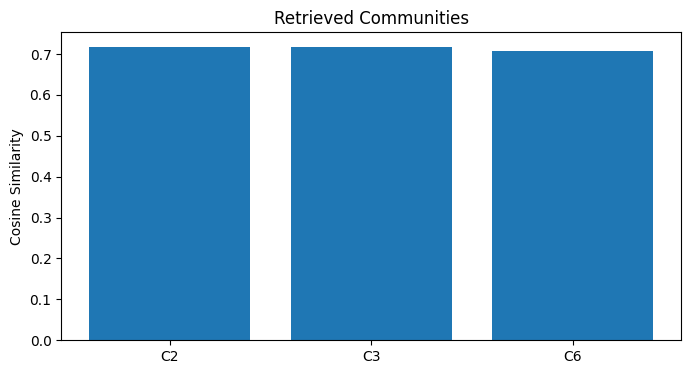

In [11]:
# ============================================================
# SECTION 10 — Visualize Retrieval
# ============================================================

visualize_retrieved_communities(
    retrieved
)

In [12]:
# ============================================================
# SECTION 11 — Build Final Context
# ============================================================

context = build_global_context(
    G,
    retrieved
)

print(
    "Retrieved Communities:",
    len(context)
)

Retrieved Communities: 3


In [13]:
# ============================================================
# SECTION 12 — Inspect Context
# ============================================================

for community in context:

    print("\n====================================")
    print(
        "COMMUNITY",
        community["community_id"]
    )
    print("====================================")

    print("\nSummary:\n")

    print(
        community["summary"][:1000]
    )

    print(
        "\nSupporting Sections:",
        len(community["sections"])
    )


COMMUNITY 2

Summary:

Scientific Summary:
              The primary focus of this biomedical research is the application of machine learning (ML) techniques, specifically random forest and XGBoost, to enhance the prognostic modeling of invasive ductal carcinoma (IDC), a predominant form of breast cancer. The study integrates multi-omics data, including transcriptomics and single-cell RNA-seq, to identify key predictors of mortality and recurrence in IDC patients. By leveraging the predictive power of ML models, the research aims to improve individualized treatment strategies, such as surgical and therapeutic decision-making, for IDC patients. The study also explores the potential of 1,2,4-oxadiazole derivatives as dual inhibitors of H

Supporting Sections: 3

COMMUNITY 3

Summary:

Scientific Summary:
              
              The main biomedical research theme revolves around the development of dual inhibitors targeting human epidermal growth factor receptor 2 (HER2) and estrogen